# 🌳 Decision Trees in Finance
### A Practical Teaching Notebook

---

**What you will learn in this notebook:**

| # | Topic |
|---|-------|
| 1 | How Decision Trees split data using impurity measures |
| 2 | Build a synthetic credit-risk dataset that mirrors real bank data |
| 3 | Train, visualise, and interpret a Decision Tree classifier |
| 4 | Understand feature importance and business rule extraction |
| 5 | Tune the tree to balance accuracy and interpretability |

> **Prerequisites:** Basic Python · `pandas` · `scikit-learn` · `matplotlib`  
> **Dataset:** Fully synthetic — 1,000 loan applicants with realistic financial features


## 📦 Section 1 — Imports & Setup

We import everything up front so the rest of the notebook runs cleanly.  
`plot_tree` and `export_text` are the key scikit-learn tools for **visualising** and **explaining** the tree.


In [1]:
# Standard data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# scikit-learn: model, visualisation, evaluation
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score)

# Suppress minor warnings for a cleaner notebook
import warnings
warnings.filterwarnings('ignore')

# Consistent plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

np.random.seed(42)   # reproducibility — same results every run
print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


---
## 🏦 Section 2 — Synthetic Credit Risk Dataset

### The Scenario

We are working for **FinBank**, a retail lender.  
Each row represents a **loan applicant**. The bank wants to predict whether the applicant will **default** within 12 months.

### Features we simulate

| Feature | Type | Description |
|---|---|---|
| `credit_score` | int | CIBIL/FICO score (300–850) |
| `annual_income` | int | Annual income in ₹ (or $) |
| `debt_to_income` | float | Total debt payments ÷ gross income |
| `loan_amount` | int | Amount being requested |
| `employment_years` | int | Years at current employer |
| `num_credit_lines` | int | Number of open credit accounts |
| `missed_payments` | int | Late payments in last 24 months |
| `collateral_value` | int | Value of asset pledged as security |

### Target

`default` → **1** = applicant defaulted, **0** = loan repaid successfully

> 💡 **Why synthetic data?**  
> Real bank datasets are confidential and governed by data-privacy laws.  
> We generate data using realistic statistical rules so the Decision Tree can  
> "rediscover" those rules — a great way to verify the model is working correctly.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE SYNTHETIC LOAN APPLICANT DATA
# We simulate 1,000 applicants with realistic financial characteristics.
# The target (default) is constructed from a logical rule that mirrors
# what real credit underwriting models look for.
# ─────────────────────────────────────────────────────────────────────────────

n = 1000  # number of loan applicants

# --- Feature simulation ---
credit_score      = np.random.randint(300, 851, n)
annual_income     = np.random.randint(180_000, 2_500_000, n)   # ₹ 1.8L – ₹25L
debt_to_income    = np.round(np.random.uniform(0.05, 0.85, n), 2)
loan_amount       = np.random.randint(50_000, 2_000_000, n)    # ₹50K – ₹20L
employment_years  = np.random.randint(0, 31, n)
num_credit_lines  = np.random.randint(1, 15, n)
missed_payments   = np.random.randint(0, 10, n)
collateral_value  = np.random.randint(0, 3_000_000, n)         # ₹0 – ₹30L

# --- Target construction (realistic underwriting logic) ---
# An applicant is more likely to default if they have:
#   • Low credit score  (< 580 is subprime)
#   • High debt-to-income ratio  (> 0.55 is risky)
#   • Multiple missed payments   (>= 3 signals distress)
#   • Low income AND high loan ask
risk_score = (
    (credit_score < 580).astype(int) * 2 +       # strong negative signal
    (debt_to_income > 0.55).astype(int) * 2 +    # strong negative signal
    (missed_payments >= 3).astype(int) * 2 +      # strong negative signal
    (annual_income < 400_000).astype(int) +        # moderate signal
    (loan_amount > annual_income * 3).astype(int)  # moderate signal
)

# Convert to binary target: risk_score ≥ 3 → default
default = (risk_score >= 3).astype(int)

# Add a small amount of noise to make it realistic (5% label flip)
noise_idx = np.random.choice(n, size=int(0.05 * n), replace=False)
default[noise_idx] = 1 - default[noise_idx]

# --- Assemble DataFrame ---
df = pd.DataFrame({
    'credit_score':     credit_score,
    'annual_income':    annual_income,
    'debt_to_income':   debt_to_income,
    'loan_amount':      loan_amount,
    'employment_years': employment_years,
    'num_credit_lines': num_credit_lines,
    'missed_payments':  missed_payments,
    'collateral_value': collateral_value,
    'default':          default
})

print(f"Dataset shape: {df.shape}")
print(f"Default rate:  {df['default'].mean():.1%}  ({df['default'].sum()} defaults out of {n})")
print()
print(df.head(8).to_string(index=False))


Dataset shape: (1000, 9)
Default rate:  60.4%  (604 defaults out of 1000)

 credit_score  annual_income  debt_to_income  loan_amount  employment_years  num_credit_lines  missed_payments  collateral_value  default
          402        1874693            0.23      1369976                11                13                6           2307539        0
          735        2224491            0.83      1577912                10                11                3           2596882        1
          570        1754486            0.65       817876                28                10                4           1006891        1
          406         753044            0.50      1657545                30                 3                5            727467        1
          371        1269385            0.19      1189904                26                 9                4            455796        0
          320        1769589            0.09      1841376                28                12    

---
## 📊 Section 3 — Exploratory Data Analysis (EDA)

Before training any model, we **look at the data**.  
This is essential in finance — understanding the distributions helps us catch data quality issues
and form hypotheses about which features will be most predictive.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY STATISTICS split by default status
# This gives us a quick view of how defaulters differ from non-defaulters
# ─────────────────────────────────────────────────────────────────────────────
summary = df.groupby('default').agg({
    'credit_score':     'mean',
    'annual_income':    'mean',
    'debt_to_income':   'mean',
    'missed_payments':  'mean',
    'loan_amount':      'mean',
}).round(1)

summary.index = ['✅ No Default (0)', '❌ Default (1)']
print("=== Mean Feature Values by Default Status ===")
print(summary.to_string())


=== Mean Feature Values by Default Status ===
                  credit_score  annual_income  debt_to_income  missed_payments  loan_amount
✅ No Default (0)         644.5      1423875.7             0.4              3.5    1022342.4
❌ Default (1)            512.7      1269873.1             0.5              5.3    1038467.9


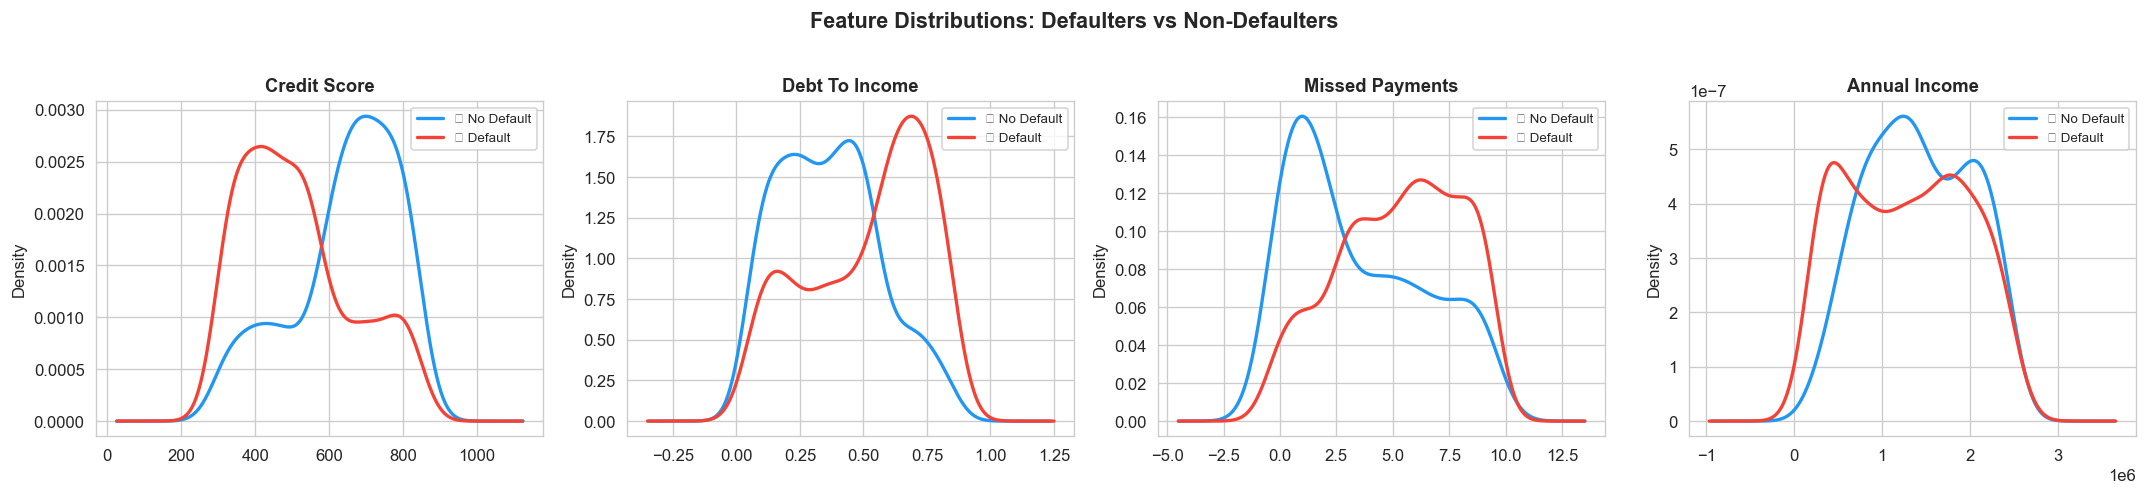

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE KEY DISTRIBUTIONS — defaulters vs non-defaulters
# Side-by-side KDE plots reveal which features separate the two classes best.
# Features with the biggest separation are likely to become key tree splits.
# ─────────────────────────────────────────────────────────────────────────────
features_to_plot = ['credit_score', 'debt_to_income', 'missed_payments', 'annual_income']
labels = {0: '✅ No Default', 1: '❌ Default'}
colors = {0: '#2196F3', 1: '#F44336'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, feat in zip(axes, features_to_plot):
    for cls in [0, 1]:
        subset = df[df['default'] == cls][feat]
        subset.plot.kde(ax=ax, label=labels[cls], color=colors[cls], linewidth=2)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions: Defaulters vs Non-Defaulters', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── INSIGHT ──────────────────────────────────────────────────────────────────
# • credit_score: clear separation — defaulters cluster at lower scores
# • debt_to_income: defaulters peak at higher ratios
# • missed_payments: defaulters have far more missed payments
# • annual_income: some separation but with overlap
# Features with clearest separation → most useful for the tree


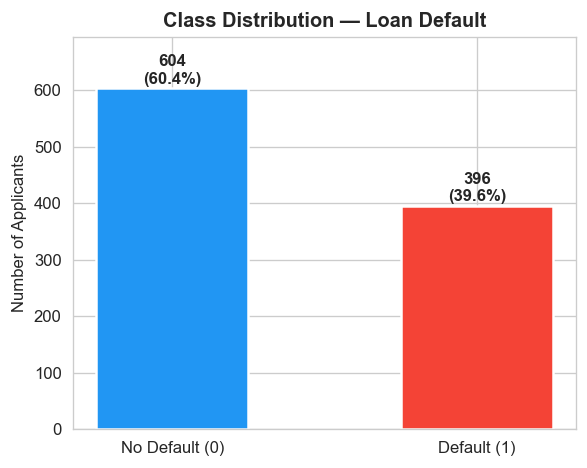

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS BALANCE CHECK
# In real credit data, defaults are rare (5–15%). Always check this!
# Imbalanced classes require special handling (covered in Section 7).
# ─────────────────────────────────────────────────────────────────────────────
counts = df['default'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values,
              color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val}\n({val/n:.1%})', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Class Distribution — Loan Default', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Applicants')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()


---
## ✂️ Section 4 — Feature Selection & Train/Test Split

We separate features (`X`) from the target (`y`), then split into training and test sets.

> ⚠️ **Finance Note:** Always use `stratify=y` when splitting credit data.  
> Without stratification, by random chance your test set might contain far fewer (or more) defaults  
> than reality — making evaluation unreliable.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE / TARGET SPLIT
# ─────────────────────────────────────────────────────────────────────────────
features = ['credit_score', 'annual_income', 'debt_to_income',
            'loan_amount', 'employment_years', 'num_credit_lines',
            'missed_payments', 'collateral_value']

X = df[features]
y = df['default']

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT — 80% train, 20% test
# stratify=y ensures the default rate is the same in both splits
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← critical for imbalanced financial data
)

print(f"Training set:  {X_train.shape[0]} samples  |  Default rate: {y_train.mean():.1%}")
print(f"Test set:      {X_test.shape[0]} samples  |  Default rate: {y_test.mean():.1%}")
print(f"\nFeatures: {features}")


Training set:  800 samples  |  Default rate: 60.4%
Test set:      200 samples  |  Default rate: 60.5%

Features: ['credit_score', 'annual_income', 'debt_to_income', 'loan_amount', 'employment_years', 'num_credit_lines', 'missed_payments', 'collateral_value']


---
## 🔢 Section 5 — Understanding Impurity Measures

Before training the model, let's build intuition for how the tree decides **where to split**.

At each node, the algorithm tries every possible split and picks the one that most reduces **impurity**.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# GINI IMPURITY — manual implementation
# Formula: Gini = 1 − Σ pᵢ²
# Interpretation: probability of misclassifying a randomly chosen sample
# Range: 0 (pure node) to 0.5 (maximum impurity for binary classification)
# ─────────────────────────────────────────────────────────────────────────────
def gini_impurity(counts):
    """
    counts: list of class counts, e.g. [80, 20] = 80 non-defaults, 20 defaults
    returns: Gini impurity score
    """
    total = sum(counts)
    return 1 - sum((c / total) ** 2 for c in counts)

# ─────────────────────────────────────────────────────────────────────────────
# ENTROPY — measures information/uncertainty
# Formula: Entropy = −Σ pᵢ · log₂(pᵢ)
# Range: 0 (pure) to 1.0 (maximum for binary)
# ─────────────────────────────────────────────────────────────────────────────
def entropy(counts):
    total = sum(counts)
    probs = [c / total for c in counts if c > 0]
    return -sum(p * np.log2(p) for p in probs)

# --- Demonstrate with realistic credit node examples ---
examples = {
    "Pure node (all repaid)":         [200, 0],
    "Mostly safe (low-risk pool)":    [160, 40],
    "Mixed node (general applicants)":[100, 100],
    "Risky pool (high-risk subgroup)": [30, 170],
    "Pure node (all defaulted)":       [0, 200],
}

print(f"{'Scenario':<40} {'Counts':>15}  {'Gini':>6}  {'Entropy':>8}")
print("─" * 78)
for label, counts in examples.items():
    g = gini_impurity(counts)
    e = entropy(counts)
    print(f"{label:<40} {str(counts):>15}  {g:>6.3f}  {e:>8.3f}")

print()
print("KEY TAKEAWAY: Lower Gini / Entropy = purer node = better split")
print("The tree ALWAYS moves toward lower impurity at each split.")


Scenario                                          Counts    Gini   Entropy
──────────────────────────────────────────────────────────────────────────────
Pure node (all repaid)                          [200, 0]   0.000    -0.000
Mostly safe (low-risk pool)                    [160, 40]   0.320     0.722
Mixed node (general applicants)               [100, 100]   0.500     1.000
Risky pool (high-risk subgroup)                [30, 170]   0.255     0.610
Pure node (all defaulted)                       [0, 200]   0.000    -0.000

KEY TAKEAWAY: Lower Gini / Entropy = purer node = better split
The tree ALWAYS moves toward lower impurity at each split.


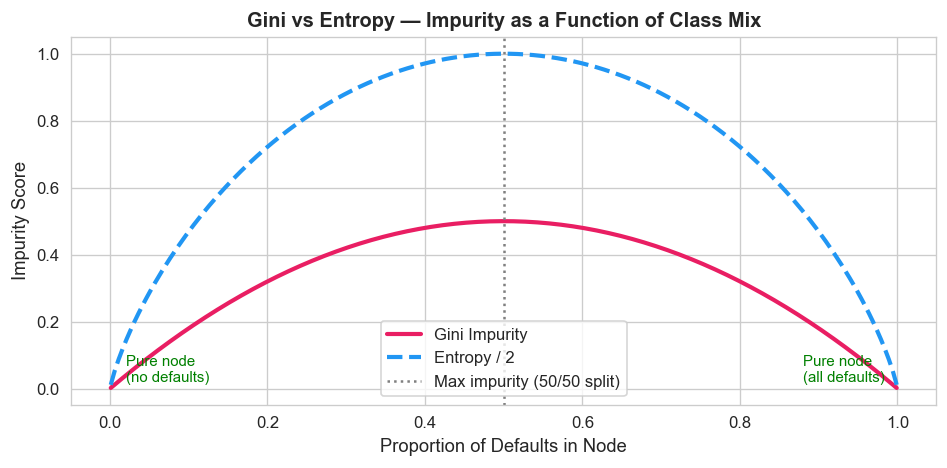

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE: How Gini changes with class distribution
# This chart is key for teaching — students see why 50/50 splits are "worst"
# ─────────────────────────────────────────────────────────────────────────────
p_default = np.linspace(0.001, 0.999, 200)   # proportion of defaults in a node
gini_vals = 1 - (p_default**2 + (1-p_default)**2)
entropy_vals = -(p_default * np.log2(p_default) + (1-p_default) * np.log2(1-p_default))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_default, gini_vals,    label='Gini Impurity', color='#E91E63', linewidth=2.5)
ax.plot(p_default, entropy_vals, label='Entropy / 2',   color='#2196F3', linewidth=2.5,
        linestyle='--')

ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Max impurity (50/50 split)')
ax.set_xlabel('Proportion of Defaults in Node', fontsize=11)
ax.set_ylabel('Impurity Score', fontsize=11)
ax.set_title('Gini vs Entropy — Impurity as a Function of Class Mix', fontsize=12, fontweight='bold')
ax.legend()
ax.annotate('Pure node\n(no defaults)', xy=(0.02, 0.02), fontsize=9, color='green')
ax.annotate('Pure node\n(all defaults)', xy=(0.88, 0.02), fontsize=9, color='green')
plt.tight_layout()
plt.show()


---
## 🤖 Section 6 — Train the Decision Tree

Now we train the model. The key hyperparameter to understand is **`max_depth`**.

| `max_depth` | Effect |
|---|---|
| 1–2 | Very simple rules; may underfit |
| 3–5 | Good balance of accuracy and interpretability ✅ |
| 10+ | Highly complex; likely to overfit |

In finance, we prefer **shallower trees** — a model that a credit committee can read and sign off on.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN THE DECISION TREE CLASSIFIER
#
# Key parameters explained:
#   max_depth=5       → tree can ask at most 5 yes/no questions per path
#   criterion='gini'  → uses Gini impurity to evaluate splits (default, fast)
#   min_samples_split → a node must have ≥20 samples before being split further
#                       (prevents the tree from creating rules for tiny groups)
#   min_samples_leaf  → each leaf must contain ≥10 samples
#                       (prevents overfitting on individual data points)
#   class_weight='balanced' → automatically adjusts for class imbalance
#                             so the minority class (defaults) gets more weight
# ─────────────────────────────────────────────────────────────────────────────
model = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',   # important: default events are minority class
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Decision Tree trained successfully!")
print(f"   Actual tree depth:  {model.get_depth()} levels")
print(f"   Number of leaves:   {model.get_n_leaves()} leaf nodes")
print(f"   Number of features: {model.n_features_in_}")


✅ Decision Tree trained successfully!
   Actual tree depth:  5 levels
   Number of leaves:   22 leaf nodes
   Number of features: 8


---
## 🌲 Section 7 — Visualise the Decision Tree

This is the most powerful feature of Decision Trees for finance:  
**you can see and read the entire model in one diagram.**

Each node shows:
- The **split condition** (e.g., `missed_payments <= 2.5`)
- The **Gini impurity** at that node
- The **number of samples** reaching that node
- The **class distribution** and predicted class


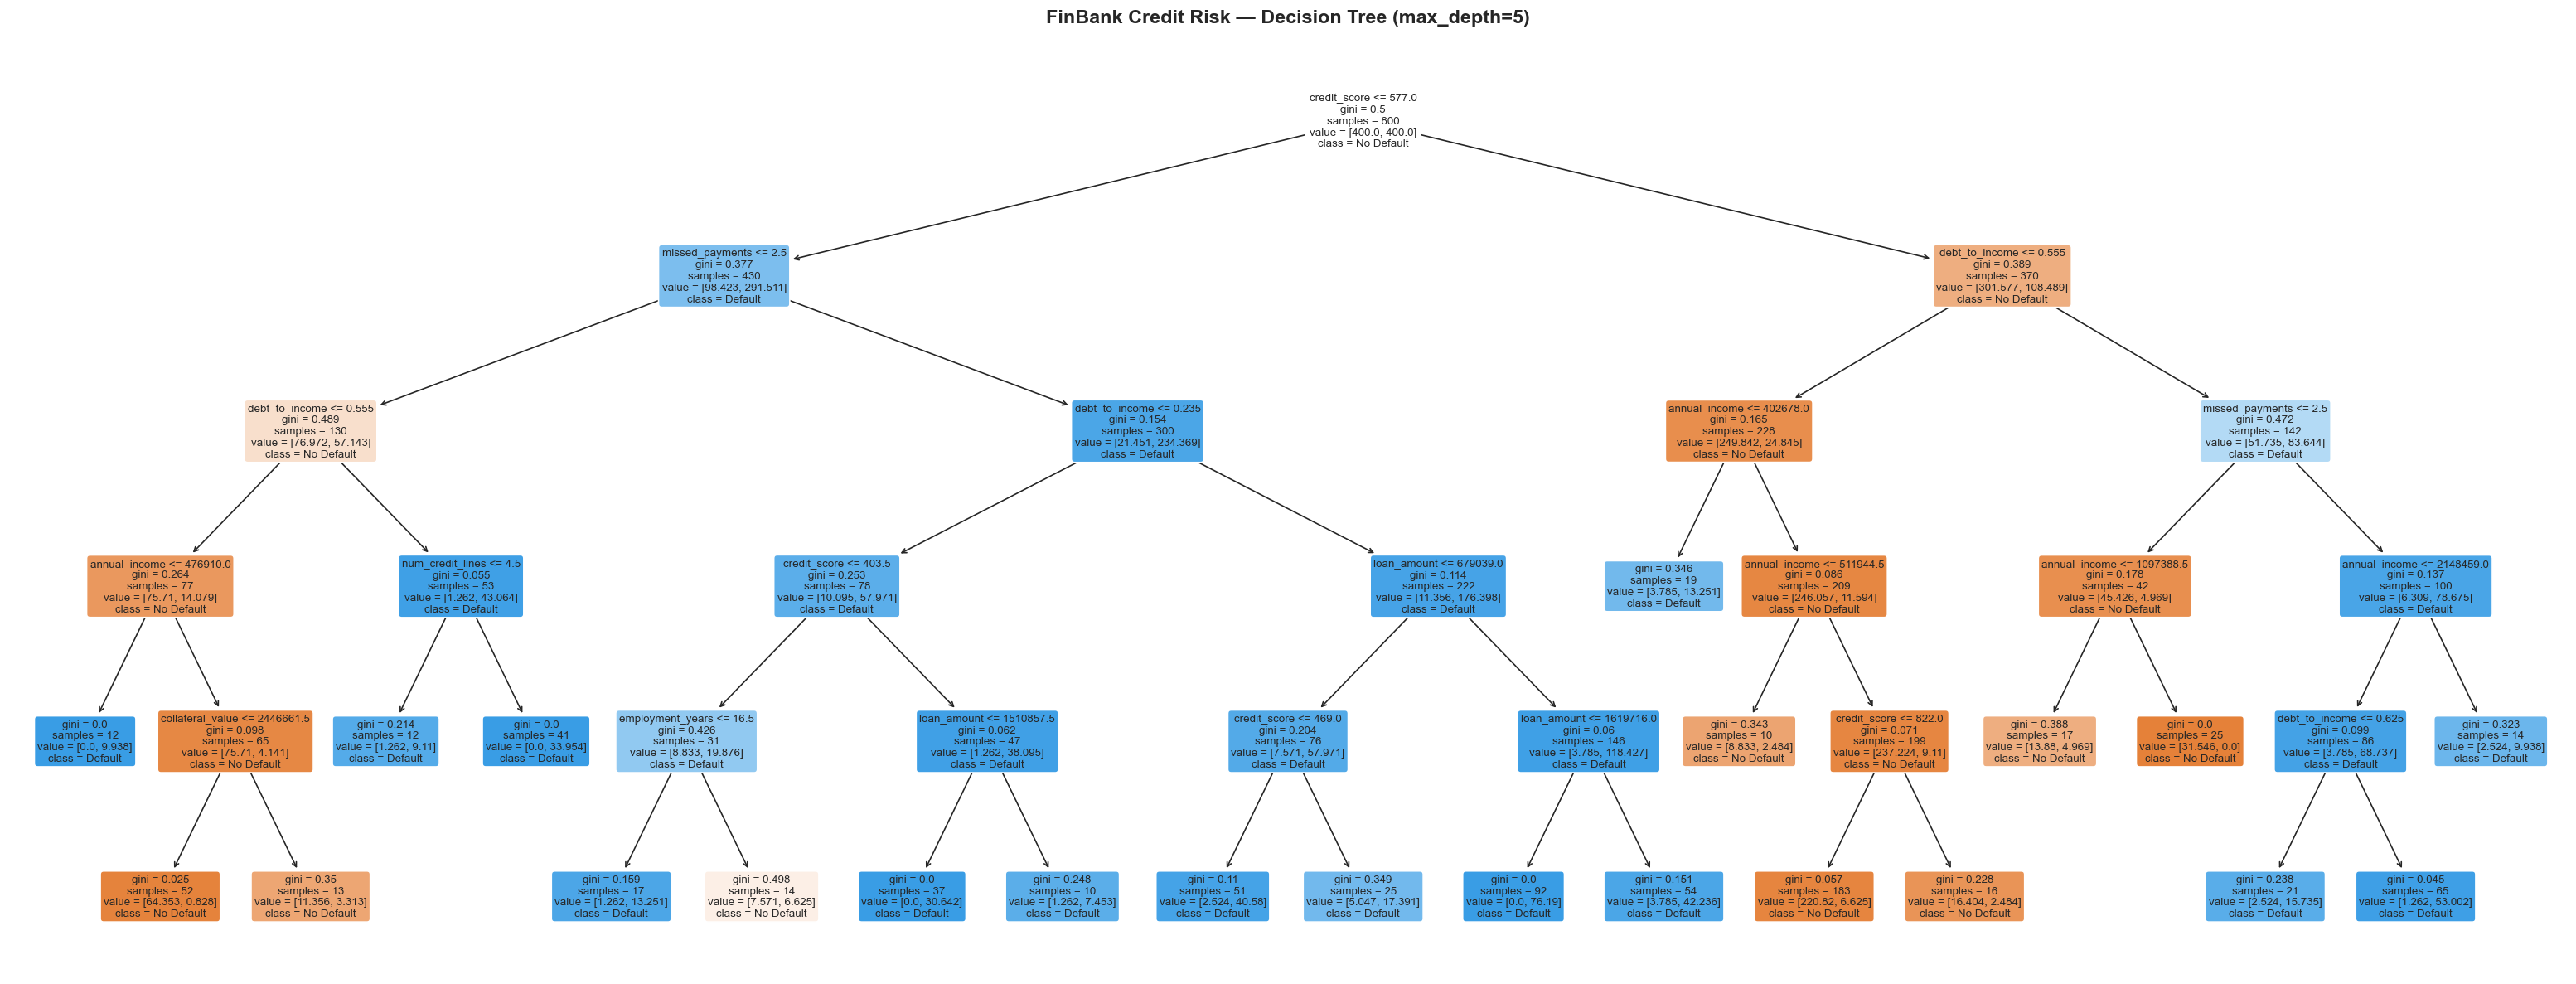

Tree saved as 'credit_risk_tree.png'


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FULL TREE VISUALISATION
# Blue nodes → majority class is "No Default" (safe)
# Orange/Red nodes → majority class is "Default" (risky)
# Darker colour = purer node (more confident prediction)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 10))

plot_tree(
    model,
    feature_names=features,
    class_names=['No Default', 'Default'],
    filled=True,         # colour nodes by predicted class
    rounded=True,        # rounded boxes look cleaner
    fontsize=8,
    impurity=True,       # show Gini value at each node
    proportion=False,    # show raw counts, not proportions
    ax=ax
)

ax.set_title('FinBank Credit Risk — Decision Tree (max_depth=5)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('credit_risk_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree saved as 'credit_risk_tree.png'")


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# TEXT RULE EXTRACTION — compliance-friendly output
# This is what you hand to a regulator or credit committee.
# Every leaf is a human-readable IF–THEN rule.
# ─────────────────────────────────────────────────────────────────────────────
text_rules = export_text(model, feature_names=features, max_depth=3)
print("=== FinBank Credit Decision Rules (Top 3 Levels) ===")
print(text_rules)
print()
print("💡 These rules can be directly embedded in:")
print("   • Credit policy documents")
print("   • Regulatory filings")
print("   • Customer rejection letters (right-to-explanation)")


=== FinBank Credit Decision Rules (Top 3 Levels) ===
|--- credit_score <= 577.00
|   |--- missed_payments <= 2.50
|   |   |--- debt_to_income <= 0.56
|   |   |   |--- annual_income <= 476910.00
|   |   |   |   |--- class: 1
|   |   |   |--- annual_income >  476910.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- debt_to_income >  0.56
|   |   |   |--- num_credit_lines <= 4.50
|   |   |   |   |--- class: 1
|   |   |   |--- num_credit_lines >  4.50
|   |   |   |   |--- class: 1
|   |--- missed_payments >  2.50
|   |   |--- debt_to_income <= 0.23
|   |   |   |--- credit_score <= 403.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- credit_score >  403.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- debt_to_income >  0.23
|   |   |   |--- loan_amount <= 679039.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- loan_amount >  679039.00
|   |   |   |   |--- truncated branch of depth 2
|--- credit_score >  577.00
|   |--- d

---
## 📋 Section 8 — Model Evaluation

We evaluate the model on the **held-out test set** (data the model has never seen).

### Key metrics in credit risk

| Metric | Formula | Finance Interpretation |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of those predicted to default, how many actually did? |
| **Recall** | TP / (TP + FN) | Of all actual defaults, how many did we catch? |
| **F1 Score** | Harmonic mean of P & R | Balance between catching defaults and avoiding false alarms |
| **AUC-ROC** | Area under ROC curve | Overall discrimination ability (0.5 = random, 1.0 = perfect) |

> ⚠️ **In credit risk, Recall (for Default class) is usually most important.**  
> Missing a default (False Negative) costs the bank the full loan amount.  
> A false alarm (False Positive) only costs a rejected application.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]   # probability of default (class 1)

print("=" * 55)
print("        CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['No Default', 'Default'],
                             digits=3))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc:.4f}")


        CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

  No Default      0.897     0.886     0.892        79
     Default      0.926     0.934     0.930       121

    accuracy                          0.915       200
   macro avg      0.912     0.910     0.911       200
weighted avg      0.915     0.915     0.915       200

AUC-ROC Score: 0.9484


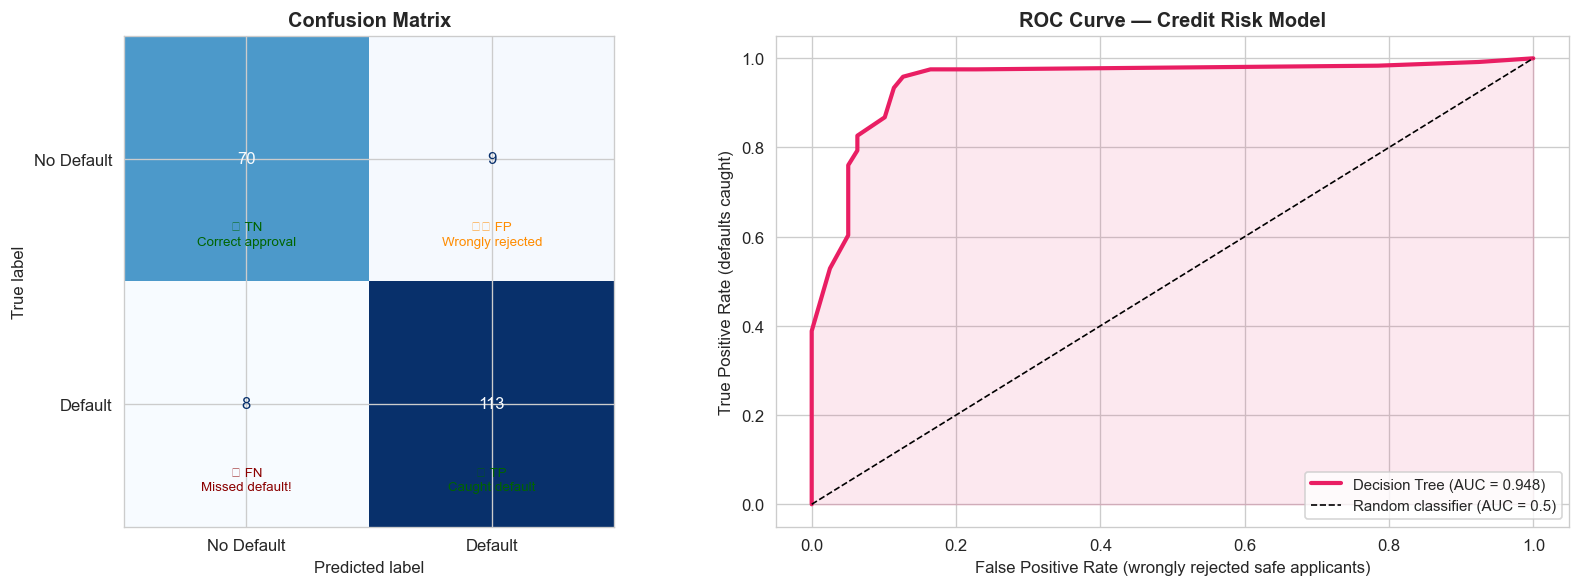

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX — visualised
# Rows = actual class, Columns = predicted class
#
#   TN = correctly identified safe loans     ← bank earns interest
#   FP = safe loans wrongly rejected         ← lost business opportunity
#   FN = defaults not caught                 ← bank loses principal ← WORST
#   TP = defaults correctly flagged          ← bank avoids loss     ← BEST
# ─────────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Confusion Matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Default', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Annotate with business impact
tn, fp, fn, tp = cm.ravel()
axes[0].text(0, 0.35, f'✅ TN\nCorrect approval', ha='center', fontsize=8, color='darkgreen')
axes[0].text(1, 0.35, f'⚠️ FP\nWrongly rejected', ha='center', fontsize=8, color='darkorange')
axes[0].text(0, 1.35, f'🚨 FN\nMissed default!', ha='center', fontsize=8, color='darkred')
axes[0].text(1, 1.35, f'✅ TP\nCaught default', ha='center', fontsize=8, color='darkgreen')

# --- Right: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#E91E63', linewidth=2.5,
             label=f'Decision Tree (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E91E63')
axes[1].set_xlabel('False Positive Rate (wrongly rejected safe applicants)', fontsize=10)
axes[1].set_ylabel('True Positive Rate (defaults caught)', fontsize=10)
axes[1].set_title('ROC Curve — Credit Risk Model', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 🔍 Section 9 — Feature Importance

Feature importance tells us **which variables the tree relied on most** to make decisions.

In finance, this is crucial for:
- **Model governance** — justifying why certain data is used
- **Fair lending compliance** — ensuring protected attributes (age, gender) aren't implicitly influential
- **Business insight** — which risk signals matter most to the model


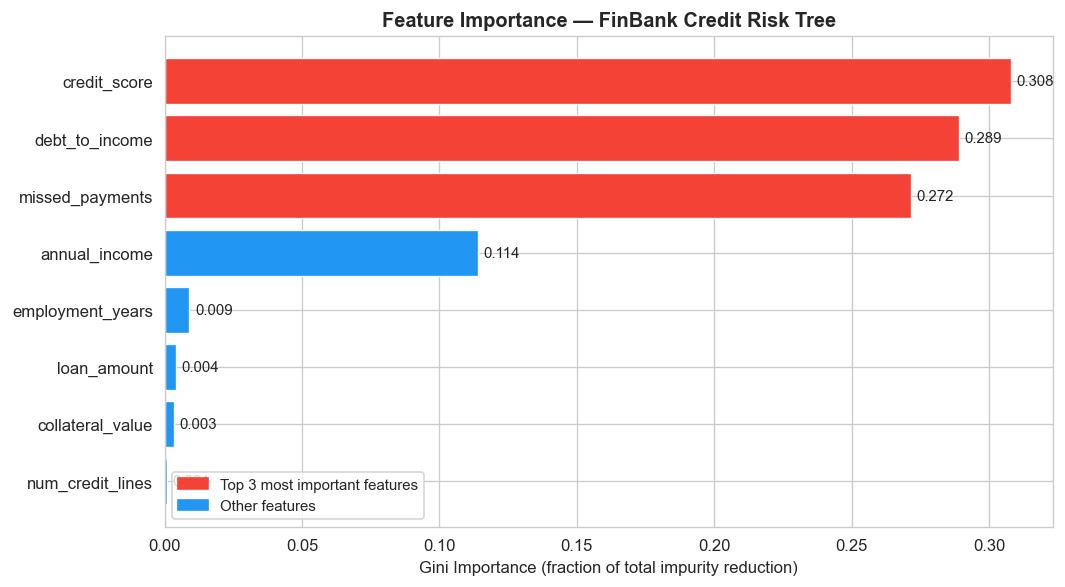


=== Feature Importance Ranking ===
         Feature  Importance
    credit_score    0.307983
  debt_to_income    0.288945
 missed_payments    0.271717
   annual_income    0.113997
employment_years    0.009082
     loan_amount    0.004073
collateral_value    0.003455
num_credit_lines    0.000747


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCES — Gini-based
# Each feature's importance = total Gini reduction it caused across all splits,
# weighted by the number of samples that passed through those splits.
# Importances are normalised to sum to 1.0.
# ─────────────────────────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)   # ascending for horizontal bar chart

# Colour code: top 3 features highlighted
colors_bar = ['#F44336' if imp >= sorted(model.feature_importances_, reverse=True)[2]
              else '#2196F3' for imp in importance_df['Importance']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors_bar, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Gini Importance (fraction of total impurity reduction)', fontsize=10)
ax.set_title('Feature Importance — FinBank Credit Risk Tree', fontsize=12, fontweight='bold')

red_patch  = mpatches.Patch(color='#F44336', label='Top 3 most important features')
blue_patch = mpatches.Patch(color='#2196F3', label='Other features')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Feature Importance Ranking ===")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))


---
## ⚙️ Section 10 — Hyperparameter Tuning: Depth vs Accuracy

One of the most important skills in applied ML is understanding **when your model is too simple or too complex**.

We sweep `max_depth` from 1 to 15 and plot training vs test accuracy.

- **Underfitting zone** (low depth): both train and test accuracy are low
- **Sweet spot** (medium depth): test accuracy peaks — this is our best model
- **Overfitting zone** (high depth): train accuracy → 100%, test accuracy drops


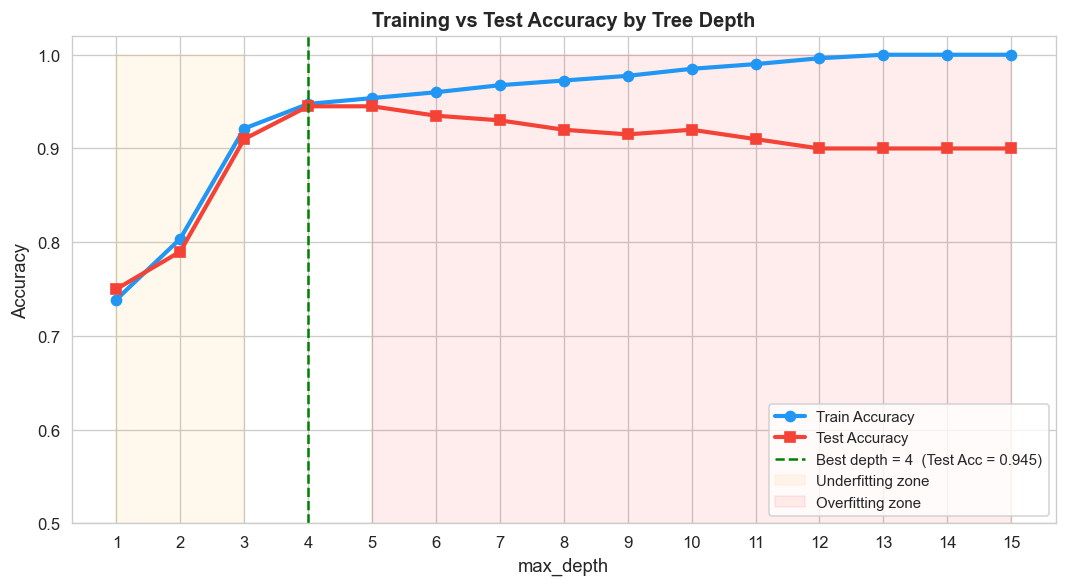

✅ Optimal max_depth = 4  |  Test Accuracy = 0.9450


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# DEPTH SWEEP — find the optimal max_depth
# We train a new tree at each depth and record train & test accuracy.
# This is a form of model selection / hyperparameter search.
# ─────────────────────────────────────────────────────────────────────────────
depths = range(1, 16)
train_acc, test_acc = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))

# Find the best depth
best_depth = depths[np.argmax(test_acc)]
best_test  = max(test_acc)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_acc, 'o-', color='#2196F3', linewidth=2.5, label='Train Accuracy')
ax.plot(depths, test_acc,  's-', color='#F44336', linewidth=2.5, label='Test Accuracy')
ax.axvline(best_depth, color='green', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_depth}  (Test Acc = {best_test:.3f})')
ax.fill_betweenx([0, 1], 1, best_depth - 1, alpha=0.07, color='orange', label='Underfitting zone')
ax.fill_betweenx([0, 1], best_depth + 1, 15, alpha=0.07, color='red', label='Overfitting zone')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Training vs Test Accuracy by Tree Depth', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.02)
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

print(f"✅ Optimal max_depth = {best_depth}  |  Test Accuracy = {best_test:.4f}")


---
## 📝 Section 11 — Translating the Tree into Business Rules

The final step in any finance ML project is **translation** — converting the model into  
policies that non-technical stakeholders (credit committees, regulators, compliance teams) can use.

Below we extract the top-level decision paths from the tree and write them as plain-English rules.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# EXTRACT DECISION PATHS FOR SAMPLE APPLICANTS
# For each test applicant we can trace the exact path through the tree —
# a complete audit trail for every automated credit decision.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.tree import _tree

def extract_rules(tree, feature_names, class_names, max_depth=3):
    """
    Print the top decision rules from a trained Decision Tree in plain English.
    Each line represents one branch condition on the path to a leaf.
    """
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined"
        for i in tree_.feature
    ]

    def recurse(node, depth, conditions):
        if depth > max_depth:
            return
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            # Leaf node
            class_idx = np.argmax(tree_.value[node])
            samples   = int(tree_.n_node_samples[node])
            label     = class_names[class_idx]
            icon      = "✅" if class_idx == 0 else "❌"
            print(f"{'  ' * depth}{icon} DECISION: {label}  [{samples} applicants reached this leaf]")
            if conditions:
                print(f"{'  ' * depth}   RULE: IF " + " AND ".join(conditions))
            print()
        else:
            feat  = feature_name[node]
            thresh = round(tree_.threshold[node], 2)
            recurse(tree_.children_left[node],  depth + 1, conditions + [f"{feat} ≤ {thresh}"])
            recurse(tree_.children_right[node], depth + 1, conditions + [f"{feat} > {thresh}"])

    print("=== FinBank Credit Risk — Decision Rules (depth ≤ 3) ===\n")
    recurse(0, 0, [])

extract_rules(model, features, ['No Default', 'Default'], max_depth=3)


=== FinBank Credit Risk — Decision Rules (depth ≤ 3) ===

      ❌ DECISION: Default  [19 applicants reached this leaf]
         RULE: IF credit_score > 577.0 AND debt_to_income ≤ 0.56 AND annual_income ≤ 402678.0



In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SCORE A NEW APPLICANT — demonstrate real-time prediction
# In production, this would come from an API call or form submission.
# ─────────────────────────────────────────────────────────────────────────────
new_applicants = pd.DataFrame([
    {   # Applicant A — strong profile
        'credit_score': 760, 'annual_income': 1_200_000,
        'debt_to_income': 0.22, 'loan_amount': 500_000,
        'employment_years': 8, 'num_credit_lines': 5,
        'missed_payments': 0, 'collateral_value': 1_500_000
    },
    {   # Applicant B — risky profile
        'credit_score': 520, 'annual_income': 280_000,
        'debt_to_income': 0.72, 'loan_amount': 900_000,
        'employment_years': 1, 'num_credit_lines': 10,
        'missed_payments': 5, 'collateral_value': 100_000
    },
    {   # Applicant C — borderline case
        'credit_score': 630, 'annual_income': 600_000,
        'debt_to_income': 0.45, 'loan_amount': 400_000,
        'employment_years': 4, 'num_credit_lines': 3,
        'missed_payments': 2, 'collateral_value': 600_000
    }
])

preds = model.predict(new_applicants)
probs = model.predict_proba(new_applicants)[:, 1]

print("=" * 58)
print("  NEW APPLICANT SCORING — FinBank Credit Risk Model")
print("=" * 58)
for i, (pred, prob) in enumerate(zip(preds, probs)):
    label = "❌ REJECT — High Default Risk" if pred == 1 else "✅ APPROVE — Low Default Risk"
    print(f"\nApplicant {chr(65+i)}:  {label}")
    print(f"  Default probability: {prob:.1%}")
    print(f"  Credit score: {new_applicants.iloc[i]['credit_score']}  |  "
          f"Debt-to-income: {new_applicants.iloc[i]['debt_to_income']}  |  "
          f"Missed payments: {int(new_applicants.iloc[i]['missed_payments'])}")


  NEW APPLICANT SCORING — FinBank Credit Risk Model

Applicant A:  ✅ APPROVE — Low Default Risk
  Default probability: 2.9%
  Credit score: 760.0  |  Debt-to-income: 0.22  |  Missed payments: 0

Applicant B:  ❌ REJECT — High Default Risk
  Default probability: 100.0%
  Credit score: 520.0  |  Debt-to-income: 0.72  |  Missed payments: 5

Applicant C:  ✅ APPROVE — Low Default Risk
  Default probability: 2.9%
  Credit score: 630.0  |  Debt-to-income: 0.45  |  Missed payments: 2


---
## 🎓 Section 12 — Summary & Key Takeaways

| Concept | What We Learned |
|---|---|
| **Splitting** | Trees greedily choose the (feature, threshold) pair that most reduces Gini/Entropy |
| **Gini Impurity** | Measures class mixing at a node; 0 = pure, 0.5 = maximum impurity |
| **max_depth** | The single most important hyperparameter; controls bias–variance trade-off |
| **Interpretability** | Every prediction has a traceable IF–THEN rule path through the tree |
| **Finance fit** | DTs align with regulatory requirements for explainable automated decisions |
| **Limitations** | Single trees overfit; in practice use Random Forests or XGBoost for accuracy |

---

### 📚 What to Study Next

1. **Random Forests** — averaging many decorrelated trees dramatically reduces variance
2. **Gradient Boosting (XGBoost, LightGBM)** — state-of-the-art for tabular financial data
3. **SHAP values** — explain predictions from any model (not just trees)
4. **Cost-sensitive learning** — assign different misclassification costs to FN vs FP

---

> 💬 **Remember:**  
> A Decision Tree is not just a model — it is a *representation of reasoning*.  
> In finance, being able to explain and defend every credit decision is as important  
> as the prediction itself. That is why the Decision Tree remains the foundation  
> of interpretable machine learning in the financial industry.
